# SOH Forecasting — dQ/ΔV formula variant

Same Transformer-encoder methodology as `soh_forecast.ipynb`, but with three changes:

1. **Sessions are split on a 1-minute gap** (instead of 10 minutes), giving finer-grained "segments".
2. **Only the first 1000 segments are used.** Raw data after segment 1000 is too noisy. The 75/25 train/test split is preserved.
3. **SOH is computed from a derived dQ/ΔV formula** (the user's formula):

$$\mathrm{SOH}^{*}_{N\text{th segment}} (\%) = \frac{\sum dQ_N / \Delta V_N}{\sum dQ_{\mathrm{ref}} / \Delta V_{\mathrm{ref}}} \times 100$$

For each segment:
- `dQ_N` = capacity charged during the segment (Ah).
- `ΔV_N` = `pack_voltage[end] − pack_voltage[start]` over the segment.
- Reference = mean of `dQ/ΔV` over the **first few full early-life segments** (large ΔSOC + meaningful ΔV).

> Requires: `pandas numpy matplotlib scikit-learn torch`


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(0)
np.random.seed(0)

CSV_PATH = "#14.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 1. Load and parse

In [2]:
RENAME = {
    "pack_voltage (V)":        "pack_voltage",
    "charge_current (A)":      "charge_current",
    "max_cell_voltage (V)":    "max_cell_voltage",
    "min_cell_voltage (V)":    "min_cell_voltage",
    "max_temperature (℃)":  "max_temperature",
    "min_temperature (℃)":  "min_temperature",
    "available_energy (kw)":   "available_energy",
    "available_capacity (Ah)": "available_capacity",
}

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={df.columns[0]: "row_idx", **RENAME})
missing = [v for v in RENAME.values() if v not in df.columns]
assert not missing, f"Expected columns missing after rename: {missing}. Got: {list(df.columns)}"
df["timestamp"] = pd.to_datetime(df["record_time"], format="%Y%m%d%H%M%S")
df = df.sort_values("timestamp").reset_index(drop=True)
print("rows:", len(df))
print("columns:", list(df.columns))
print("range:", df["timestamp"].min(), "->", df["timestamp"].max())
df.head()


rows: 793132
columns: ['row_idx', 'record_time', 'soc', 'pack_voltage', 'charge_current', 'max_cell_voltage', 'min_cell_voltage', 'max_temperature', 'min_temperature', 'available_energy', 'available_capacity', 'timestamp']
range: 2019-07-26 01:07:17 -> 2021-11-15 18:58:44


,row_idx,record_time,soc,pack_voltage,charge_current,max_cell_voltage,min_cell_voltage,max_temperature,min_temperature,available_energy,available_capacity,timestamp
0,0,20190726010717,15.6,323.8,-46.20001,3.602,3.587,37,35,7.04,21.17,2019-07-26 01:07:17
1,1,20190726010725,15.6,324.2,-52.20001,3.618,3.597,37,35,7.08,21.31,2019-07-26 01:07:25
2,2,20190726010733,15.6,324.4,-52.20001,3.621,3.599,37,35,7.12,21.41,2019-07-26 01:07:33
3,3,20190726010741,16.0,324.6,-52.20001,3.623,3.600,37,35,7.16,21.54,2019-07-26 01:07:41
4,4,20190726010749,16.0,324.7,-52.20001,3.624,3.602,37,35,7.20,21.65,2019-07-26 01:07:49


## 2. Segment by **1-minute** time gap

A new session starts whenever the gap to the previous sample exceeds `GAP_MINUTES = 1`. We keep a session as a charging segment only if the median current is negative **and** the session has at least `MIN_ROWS` samples (≈80 s of data at 8 s sampling).


In [3]:
GAP_MINUTES = 1
MIN_ROWS = 10   # drop sessions shorter than this many samples

dt = df["timestamp"].diff().dt.total_seconds().fillna(0)
df["session"] = (dt > GAP_MINUTES * 60).cumsum()
print("Distinct sessions:", df["session"].nunique())


Distinct sessions: 1737


In [4]:
def aggregate_session(g):
    soc_start = g["soc"].iloc[0]; soc_end = g["soc"].iloc[-1]
    cur = g["charge_current"]
    if cur.median() >= -1.0:               # not actually charging
        return None
    if len(g) < MIN_ROWS:
        return None
    duration_s = (g["timestamp"].iloc[-1] - g["timestamp"].iloc[0]).total_seconds()
    v_start = g["pack_voltage"].iloc[0]; v_end = g["pack_voltage"].iloc[-1]
    return pd.Series({
        "t_start":              g["timestamp"].iloc[0],
        "t_end":                g["timestamp"].iloc[-1],
        "duration_min":         duration_s / 60.0,
        "soc_start":            soc_start,
        "soc_end":              soc_end,
        "delta_soc":            soc_end - soc_start,
        "v_pack_mean":          g["pack_voltage"].mean(),
        "v_pack_max":           g["pack_voltage"].max(),
        "v_pack_min":           g["pack_voltage"].min(),
        "v_start":              v_start,
        "v_end":                v_end,
        "delta_v":              v_end - v_start,
        "i_chg_mean_abs":       cur.abs().mean(),
        "i_chg_max_abs":        cur.abs().max(),
        "temp_max_mean":        g["max_temperature"].mean(),
        "temp_min_mean":        g["min_temperature"].mean(),
        "temp_spread_mean":     (g["max_temperature"] - g["min_temperature"]).mean(),
        "cell_v_max_mean":      g["max_cell_voltage"].mean(),
        "cell_v_spread_mean":   (g["max_cell_voltage"] - g["min_cell_voltage"]).mean(),
        "cap_charged_ah":       g["available_capacity"].iloc[-1] - g["available_capacity"].iloc[0],
        "energy_charged_kwh":   g["available_energy"].iloc[-1]   - g["available_energy"].iloc[0],
        "available_capacity_max": g["available_capacity"].max(),
    })

records = []
for sid, g in df.groupby("session", sort=True):
    rec = aggregate_session(g)
    if rec is not None:
        rec["session"] = sid
        records.append(rec)

cycles = pd.DataFrame(records).reset_index(drop=True)
cycles["cycle_idx"] = np.arange(len(cycles))
cycles["days_since_start"] = (cycles["t_start"] - cycles["t_start"].iloc[0]).dt.total_seconds() / 86400.0
print(f"Detected {len(cycles)} charging segments over {cycles['days_since_start'].iloc[-1]:.1f} days")
cycles.head()


Detected 1635 charging segments over 843.7 days


,t_start,t_end,duration_min,soc_start,soc_end,delta_soc,v_pack_mean,v_pack_max,v_pack_min,v_start,...,temp_min_mean,temp_spread_mean,cell_v_max_mean,cell_v_spread_mean,cap_charged_ah,energy_charged_kwh,available_capacity_max,session,cycle_idx,days_since_start
0,2019-07-26 01:07:17,2019-07-26 02:26:14,78.950000,15.6,67.2,51.6,335.907407,352.2,323.8,323.8,...,36.612795,1.895623,3.749069,0.022658,70.32000,23.39,91.49000,0,0,0.000000
1,2019-07-26 22:12:17,2019-07-26 23:27:16,74.983333,12.4,81.6,69.2,340.791652,365.7,323.0,323.0,...,38.280639,1.012433,3.809773,0.030721,94.00000,31.28,110.98000,1,1,0.878472
2,2019-07-27 09:08:28,2019-07-27 10:46:00,97.533333,28.0,100.0,72.0,357.587978,381.3,328.9,328.9,...,37.939891,1.479508,3.993488,0.027977,97.83000,32.54,136.16000,2,2,1.334155
3,2019-07-27 21:28:20,2019-07-27 21:31:00,2.666667,44.8,47.2,2.4,336.290476,337.1,334.9,334.9,...,40.428571,2.000000,3.759619,0.030190,3.35999,1.11,64.18999,6,3,1.847951
4,2019-07-28 23:53:31,2019-07-29 01:45:19,111.800000,12.4,99.6,87.2,353.836541,381.3,323.3,323.3,...,39.013398,1.708892,3.952616,0.028957,118.36000,39.38,135.34000,7,4,2.948773


## 3. Truncate to the first 1000 segments

Beyond segment 1000 the raw signal is too noisy; we cap there.


In [5]:
N_KEEP = 1000
cycles = cycles.iloc[:N_KEEP].reset_index(drop=True)
cycles["cycle_idx"] = np.arange(len(cycles))   # re-index so it's contiguous 0..N-1
print(f"Using first {len(cycles)} segments out of original detection.")


Using first 1000 segments out of original detection.


## 4. SOH from the dQ/ΔV formula

$$\mathrm{SOH}^{*}_N (\%) = \frac{dQ_N / \Delta V_N}{dQ_{\mathrm{ref}} / \Delta V_{\mathrm{ref}}} \times 100$$

We compute SOH on **full early-life segments** (large ΔSOC + meaningful ΔV), use their mean dQ/ΔV as the reference, smooth with a rolling median, and linearly interpolate onto every segment so each one has a label.


Full segments used as SOH anchors: 429 of 1000
Reference (dQ/ΔV)_ref = 1.9696  (averaged over first 5 full segments)


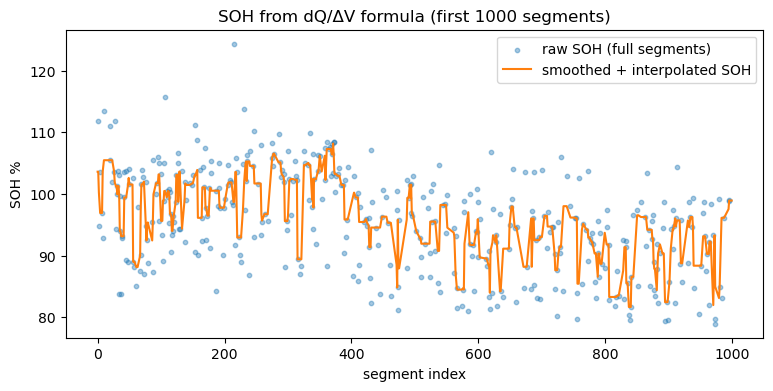

In [6]:
FULL_DELTA_SOC = 60.0   # what counts as a "full" segment (for both reference and SOH anchors)
MIN_DELTA_V    = 5.0    # filter unreliable segments before computing dQ/dV
REF_HEAD       = 5      # number of early full segments averaged for the reference
ROLL_WINDOW    = 5      # rolling-median smoothing window

full_mask = (cycles["delta_soc"] >= FULL_DELTA_SOC) & (cycles["delta_v"] >= MIN_DELTA_V)
full = cycles[full_mask].copy().reset_index(drop=True)
print(f"Full segments used as SOH anchors: {len(full)} of {len(cycles)}")

full["dq_over_dv"] = full["cap_charged_ah"] / full["delta_v"]
ref = full["dq_over_dv"].iloc[:REF_HEAD].mean()
print(f"Reference (dQ/ΔV)_ref = {ref:.4f}  (averaged over first {REF_HEAD} full segments)")

full["soh_pct_raw"]    = 100.0 * full["dq_over_dv"] / ref
full["soh_pct_smooth"] = full["soh_pct_raw"].rolling(ROLL_WINDOW, min_periods=1, center=True).median()

# Interpolate the smoothed SOH onto every segment in `cycles` by segment index
cycles["soh_pct"] = np.interp(cycles["cycle_idx"], full["cycle_idx"], full["soh_pct_smooth"])

plt.figure(figsize=(9, 4))
plt.scatter(full["cycle_idx"], full["soh_pct_raw"], s=10, alpha=0.4, label="raw SOH (full segments)")
plt.plot(cycles["cycle_idx"], cycles["soh_pct"], color="C1", label="smoothed + interpolated SOH")
plt.xlabel("segment index"); plt.ylabel("SOH %"); plt.legend()
plt.title("SOH from dQ/ΔV formula (first 1000 segments)")
plt.show()


## 5. Build windows and temporal split

In [7]:
FEATURE_COLS = [
    "duration_min",
    "v_pack_mean", "v_pack_max", "v_pack_min", "delta_v",
    "i_chg_mean_abs", "i_chg_max_abs",
    "temp_max_mean", "temp_min_mean", "temp_spread_mean",
    "cell_v_max_mean", "cell_v_spread_mean",
    "cap_charged_ah", "energy_charged_kwh",
    "available_capacity_max",
    "days_since_start",
    "soh_pct",  # current SOH is also an input feature for the next-segment forecast
]
WINDOW = 120
HORIZON = 1
TRAIN_FRAC = 0.75

X_all = cycles[FEATURE_COLS].values.astype(np.float32)
y_all = cycles["soh_pct"].values.astype(np.float32)

split = int(len(cycles) * TRAIN_FRAC)
print(f"Train segments 0..{split-1}  |  Test segments {split}..{len(cycles)-1}")

scaler = StandardScaler().fit(X_all[:split])
X_scaled = scaler.transform(X_all).astype(np.float32)

def make_windows(X, y, window, horizon, start, end):
    Xs, ys = [], []
    for i in range(start, end - window - horizon + 1):
        Xs.append(X[i:i+window])
        ys.append(y[i + window + horizon - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train, y_train = make_windows(X_scaled, y_all, WINDOW, HORIZON, 0, split)
X_test,  y_test  = make_windows(X_scaled, y_all, WINDOW, HORIZON, split - WINDOW, len(cycles))
print("Train windows:", X_train.shape, "Test windows:", X_test.shape)


Train segments 0..749  |  Test segments 750..999
Train windows: (630, 120, 17) Test windows: (250, 120, 17)


In [8]:
class CycleWindowDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X); self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

val_n = max(32, int(0.1 * len(X_train)))
train_ds = CycleWindowDS(X_train[:-val_n], y_train[:-val_n])
val_ds   = CycleWindowDS(X_train[-val_n:], y_train[-val_n:])
test_ds  = CycleWindowDS(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=128)
test_dl  = DataLoader(test_ds,  batch_size=128)
print("train", len(train_ds), "val", len(val_ds), "test", len(test_ds))


train 567 val 63 test 250


## 6. Transformer encoder model

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class SOHTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, layers=3, dim_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )
    def forward(self, x):
        h = self.pos(self.input_proj(x))
        h = self.encoder(h)
        return self.head(h[:, -1]).squeeze(-1)

model = SOHTransformer(n_features=len(FEATURE_COLS)).to(DEVICE)
print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


SOHTransformer(
  (input_proj): Linear(in_features=17, out_features=64, bias=True)
  (pos): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, o

## 7. Train

In [ ]:
EPOCHS = 80
LR = 1e-3
PATIENCE = 30

opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.MSELoss()

best_val = float("inf"); best_state = None; bad = 0
hist = {"train": [], "val": []}

for epoch in range(EPOCHS):
    model.train(); tr = 0.0; n = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tr += loss.item() * len(xb); n += len(xb)
    sched.step(); tr /= n

    model.eval(); vl = 0.0; nv = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl += loss_fn(model(xb), yb).item() * len(xb); nv += len(xb)
    vl /= nv
    hist["train"].append(tr); hist["val"].append(vl)

    if vl < best_val - 1e-6:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d}  train {tr:.5f}  val {vl:.5f}  best {best_val:.5f}")
    if bad >= PATIENCE:
        print(f"Early stop at epoch {epoch}, best val {best_val:.5f}")
        break

model.load_state_dict(best_state)

plt.figure(figsize=(7, 3))
plt.plot(hist["train"], label="train")
plt.plot(hist["val"],   label="val")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("Loss")
plt.show()


epoch   0  train 9215.11900  val 8456.24609  best 8456.24609
epoch   5  train 7412.19538  val 6633.17432  best 6633.17432
epoch  10  train 4593.94927  val 3805.39233  best 3805.39233
epoch  15  train 1544.84974  val 1005.78162  best 1005.78162
epoch  20  train 73.48202  val 16.09816  best 8.53796
epoch  25  train 57.64881  val 13.72793  best 8.53796
epoch  30  train 41.78055  val 2.92604  best 2.15478
epoch  35  train 41.24811  val 1.78977  best 1.78977
epoch  40  train 42.18606  val 5.39104  best 1.78977
epoch  45  train 41.50745  val 1.34049  best 1.17855
epoch  50  train 38.92029  val 3.35784  best 1.17855
epoch  55  train 41.64962  val 3.16783  best 1.17855
epoch  60  train 38.80642  val 2.20402  best 1.17855


## 8. Evaluate

Same baselines as before — **persistence** and **linear extrapolation** — now reported on the SOH **percentage** scale.


In [ ]:
@torch.no_grad()
def predict(model, dl):
    model.eval()
    out = []
    for xb, _ in dl:
        out.append(model(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

y_pred = predict(model, test_dl)

# Persistence: last SOH in each test window (undo standardisation)
soh_idx = FEATURE_COLS.index("soh_pct")
mu, sg = scaler.mean_[soh_idx], scaler.scale_[soh_idx]
y_persist = X_test[:, -1, soh_idx] * sg + mu

# Linear extrapolation fit on training segments
train_idx = np.arange(split)
coef = np.polyfit(train_idx, y_all[:split], 1)
test_cycle_idx = np.arange(split, len(cycles))[-len(y_test):]
y_linear = np.polyval(coef, test_cycle_idx)

def report(name, yt, yp):
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    print(f"{name:14s}  MAE {mean_absolute_error(yt, yp):.4f}  RMSE {rmse:.4f}  R2 {r2_score(yt, yp):.4f}")

report("Transformer", y_test, y_pred)
report("Persistence", y_test, y_persist)
report("Linear",      y_test, y_linear)


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(cycles["cycle_idx"], cycles["soh_pct"], color="lightgray", label="Actual SOH")
# plt.plot(test_cycle_idx, y_test,    "k",     lw=2, label="test true")
plt.plot(test_cycle_idx, y_pred,    "C0",    label="Transformer")
# plt.plot(test_cycle_idx, y_linear,  "C2--",  label="Linear")
# plt.plot(test_cycle_idx, y_persist, "C3:",   label="Persistence")
plt.axvline(split, color="red", ls="--", lw=1, label="train/test split")
plt.xlabel("segment"); plt.ylabel("SOH %")
# plt.title("SOH forecast on held-out segments (dQ/ΔV formula, first 1000 segments)")
plt.legend()
plt.show()


In [ ]:
Notes & next steps

Tune FULL_DELTA_SOC: drop it (e.g. 40) if too few full segments are detected (printed in step 4); raise it (e.g. 80) for cleaner labels at the cost of fewer anchors.
Tune MIN_DELTA_V: dQ/ΔV blows up when ΔV is tiny. Raise this threshold if the raw SOH scatter is wild.
Reference window REF_HEAD: averaging more early full segments stabilises the reference but assumes the battery hasn't degraded much in those first few.
The 1-minute split typically produces many fragment segments; the formula's dQ/ΔV is most meaningful on near-full segments, which is why we restrict the SOH anchors to delta_soc >= FULL_DELTA_SOC.